In [31]:
import pandas as pd
import numpy as np
import shap
from xgboost import XGBRegressor
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings(action='once')

### Data Imports & Cleaning

In [32]:
data = pd.read_csv("data/cafc.csv")
french=['Type de plainte reçue', 
        'Pays',
        'Type de plainte reçue',
        'Pays',
        'Catégories thématiques sur la fraude et la cybercriminalité',
        'Méthode de sollicitation',
        'Genre',
        'Langue de correspondance',
        'Province/État',
        'Type de plainte']

col_rename = {
"Numéro d'identification / Number ID":"ID",
'Date Received / Date reçue':"Date",
"Fraud and Cybercrime Thematic Categories":"Category",
"Victim Age Range / Tranche d'âge des victimes":"Age",
"Number of Victims / Nombre de victimes":"Victim Count",
"Dollar Loss /pertes financières":"Dollar Loss",
"Province/State":"Province"
}

# Change Items to English & correct value types
data = data.drop(columns = french)
data.rename(columns = col_rename, inplace=True)
data = data[data["Dollar Loss"] != "$0.00"]
data["Dollar Loss"] = data["Dollar Loss"].replace('[\$,]', '', regex=True).astype(float)
data = data.replace(["Prefer not to say","Other/unknown","Not Specified","Not Available", "'Not Available / non disponible"], np.nan)
data['Age'] = data['Age'].str.strip().str.strip("'\"")

# Drop certain unwanted variables
age_drop = [
"Deceased / Décédé",
"Business / Entreprise",
]
data = data[~data["Age"].isin(age_drop)]


# Filter to Canada Only
data['Date'] = pd.to_datetime(data['Date'])
data = data[data["Country"]=="Canada"]

data.head()

<>:27: SyntaxWarning: invalid escape sequence '\$'


,ID,Date,Complaint Received Type,Country,Province,Category,Solicitation Method,Gender,Language of Correspondence,Age,Complaint Type,Victim Count,Dollar Loss
5,350313,2025-09-29,Phone,Canada,Alberta,Investments,Internet,Male,English,70 - 79,Victim,1,20000.00
9,350317,2025-09-29,Phone,Canada,Quebec,Service,Internet,NaN,French,20 - 29,Victim,1,596.67
14,350322,2025-09-29,Phone,Canada,Quebec,Service,Internet-social network,Male,French,50 - 59,Victim,1,599.01
15,350323,2025-09-29,Phone,Canada,Quebec,Spear Phishing,Email,NaN,French,NaN,Victim,1,4649.05
19,350327,2025-09-29,Phone,Canada,Quebec,Spear Phishing,Email,NaN,French,NaN,Victim,1,50294.82


### XGBoost

In [33]:
X_values = [
    'Date', 'Complaint Received Type','Province',
    'Category', 'Solicitation Method', 'Gender',
    'Age', 'Complaint Type'
]

X = data[X_values]
y = data["Dollar Loss"]

X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['DayOfWeek'] = X['Date'].dt.dayofweek
X = X.drop('Date', axis=1)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2)
model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1)
model.fit(X_train, np.log1p(y_train))
preds = model.predict(X_test)

/tmp/ipykernel_22501/2200886022.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Date'] = pd.to_datetime(X['Date'])
/tmp/ipykernel_22501/2200886022.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Year'] = X['Date'].dt.year
/tmp/ipykernel_22501/2200886022.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

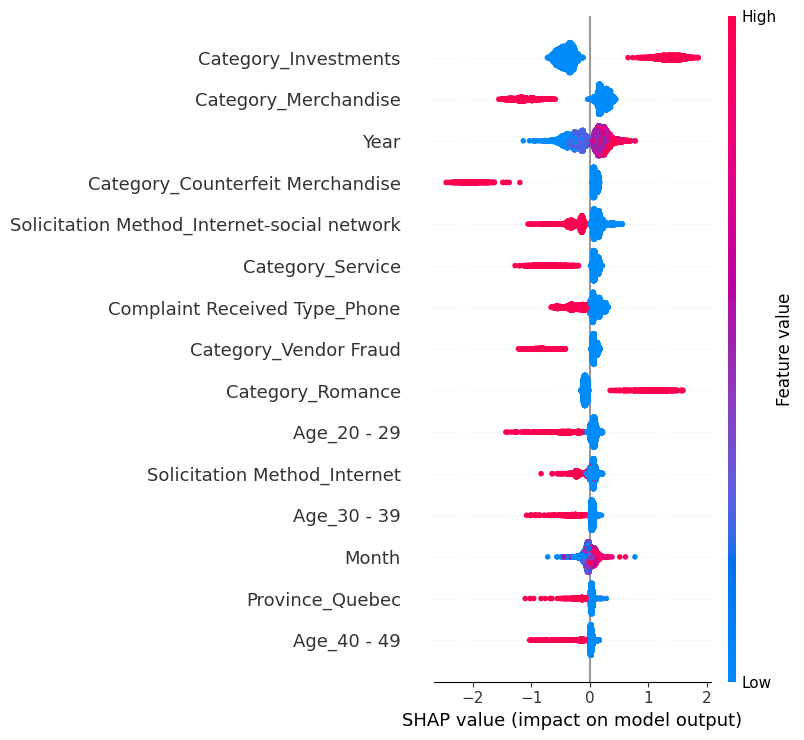

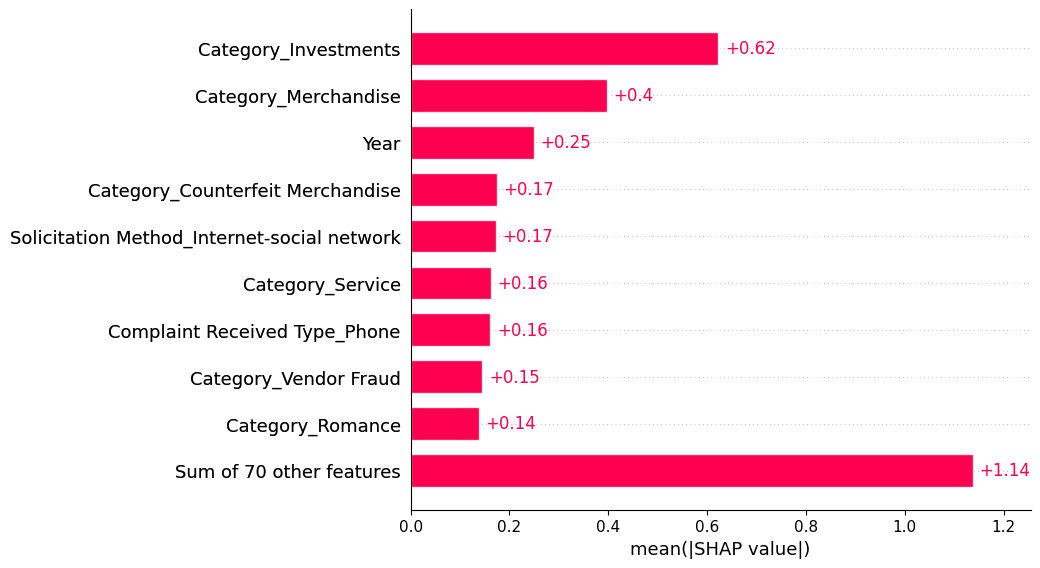

In [35]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

#Shap plots to see magnitudes
shap.summary_plot(shap_values, X_test, max_display=15)
shap.plots.bar(shap_values)

### Model Eval

In [36]:
preds_actual = np.expm1(preds)

print(f"R²: {r2_score(y_test, preds_actual):.3f}")
print(f"R² (log space): {r2_score(np.log1p(y_test), preds):.3f}")
print(f"MAE: ${mean_absolute_error(y_test, preds_actual):,.0f}")
print(f"Median actual: ${y_test.median():,.0f}")

R²: -0.001
R² (log space): 0.474
MAE: $37,539
Median actual: $2,500


### Interpretation
Due to the large variation in Dollars Lost the extreme values require us to either cut them out or use a log model. Previously I removed the edge cases, but this time I wanted to try to use log(Dollars Loss). The model in log space performs well, but when scaled back it essentially explains nothing. For this particular case, it's overwhelmingly a good idea to trim the extremes.

SHAP wise we have a similar conclusion to my previous linear model where investments and romance were the most effective fraud techniques. My prior paper went into it more, but the populations effected were fairly confined. Younger men tended to fall for investment scams and older female individuals tended to fall for romance scams.